# additional analysis to do the following
1. quantify the graded gene expression using DPT (pseudotime) and compare that agains our principle curve (pseudocluster) --> **this is `6_pseudotime` for snRNAseq analysis now**
2. find the genes's spatial autocorrelation 
3. variogram: semi-variacen as the function of physical distance. 

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
allmeshes = utils.load_mesh()

import squidpy as sq
import scanpy as sc

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [95]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_new.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 


rm_cell_ids = adata_mer.obs['leiden']!='5'
adata_mer = adata_mer[rm_cell_ids,:]
adata_mer.shape
adata_mer.X = adata_mer.X * 1e4

In [96]:
rm_cell_ids.shape, rm_cell_ids.sum()

((2651,), np.int64(2252))

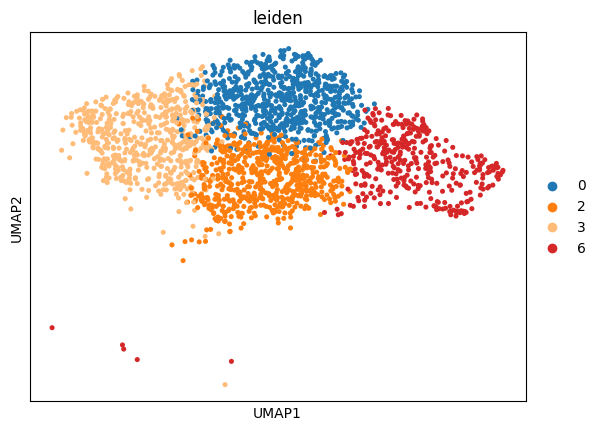

In [97]:
sc.pl.umap(adata_mer, color = 'leiden')

In [98]:
df = pd.read_csv('/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/results_to_share/spatial_with_pseudocluster.csv')
gradient = df['pseudocluster'][rm_cell_ids.values].values
adata_mer.obs['pc'] = gradient

/scratch/fast/1061367/ipykernel_24286/2413217901.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_mer.obs['pc'] = gradient


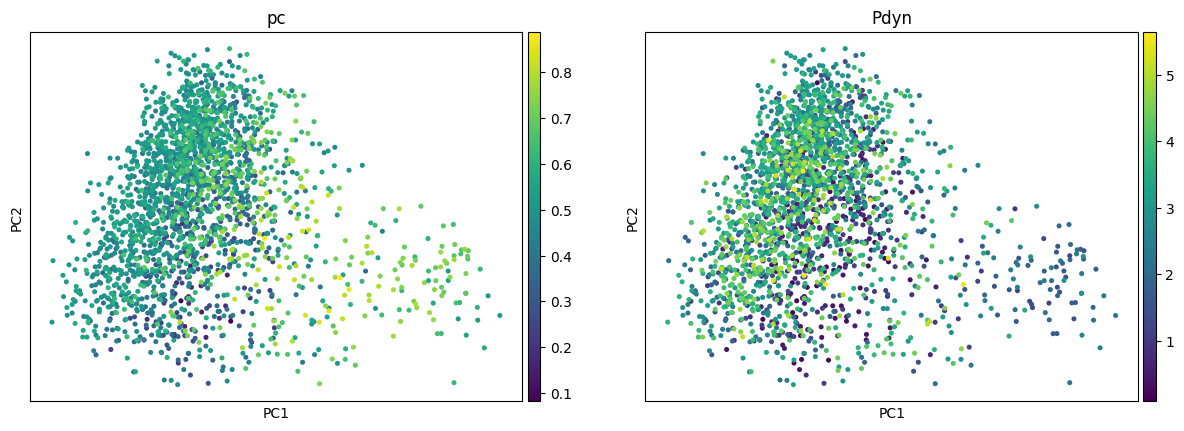

In [99]:
sc.pp.normalize_total(adata_mer)
sc.pp.log1p(adata_mer)
sc.tl.pca(adata_mer, n_comps=10)
sc.pl.pca(adata_mer, color = ['pc','Pdyn'])

# simple regression 
(not sure how to explain this result, only 28% of variance/gradients can be explained by spatial coordinates) 

In [100]:
import statsmodels.api as sm

In [101]:
gradient = adata_mer.obsm['X_pca'][:, 0]

df = adata_mer.obs[['x_CCF','y_CCF','z_CCF']]  # or your spatial axes
df['grad'] = gradient
X = sm.add_constant(df[['x_CCF','y_CCF','z_CCF']])
model = sm.OLS(df['grad'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   grad   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     10.62
Date:                Tue, 03 Jun 2025   Prob (F-statistic):           6.25e-07
Time:                        16:42:09   Log-Likelihood:                -6579.8
No. Observations:                2252   AIC:                         1.317e+04
Df Residuals:                    2248   BIC:                         1.319e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.0025      6.379      5.017      0.0

/scratch/fast/1061367/ipykernel_24286/994654345.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['grad'] = gradient


# diffusion map + pseudotime
and compare with our own pseudoclusters  
**move this to the snRNAseq analysis for now..**

# spatial gradient with Moron's I

In [102]:
sq.gr.spatial_neighbors(adata_mer, coord_type="generic", spatial_key="spatial", n_neighs = 10)

In [103]:
sq.gr.spatial_autocorr(adata_mer,attr = 'obs', mode='moran', genes='pc')
adata_mer.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
pc,0.538112,0.0,0.000077,0.0


In [104]:
sq.gr.spatial_autocorr(adata_mer, mode='moran', genes=['Shox2','Tacr3','Gpr101','Dbh'])
adata_mer.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
Tacr3,0.516324,0.0,0.000077,0.0
Gpr101,0.320533,0.0,0.000077,0.0
Shox2,0.280621,0.0,0.000077,0.0
Dbh,0.157110,0.0,0.000077,0.0


In [105]:
sq.gr.spatial_autocorr(adata_mer,attr = 'obs', mode='moran', genes='pc')
adata_mer.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
pc,0.538112,0.0,0.000077,0.0


In [106]:
sq.gr.spatial_autocorr(adata_mer,attr = 'obs', mode='moran', genes='pc')
adata_mer.uns['moranI']

,I,pval_norm,var_norm,pval_norm_fdr_bh
pc,0.538112,0.0,0.000077,0.0


In [107]:
moranI_allgenes = sq.gr.spatial_autocorr(adata_mer, mode='moran', genes=adata_mer.var_names, copy = True)
moranI_allgenes

,I,pval_norm,var_norm,pval_norm_fdr_bh
Pdyn,0.531803,0.000000e+00,0.000077,0.000000e+00
Tacr3,0.516324,0.000000e+00,0.000077,0.000000e+00
Oprm1,0.508638,0.000000e+00,0.000077,0.000000e+00
Tmem178,0.476262,0.000000e+00,0.000077,0.000000e+00
Col6a5,0.465125,0.000000e+00,0.000077,0.000000e+00
...,...,...,...,...
Galntl6,0.051106,2.084329e-09,0.000077,2.111224e-09
Slc6a20a,0.044678,1.341455e-07,0.000077,1.354395e-07
Fgfr1,0.042923,3.819964e-07,0.000077,3.844451e-07
Snap25,0.042276,5.561013e-07,0.000077,5.578780e-07


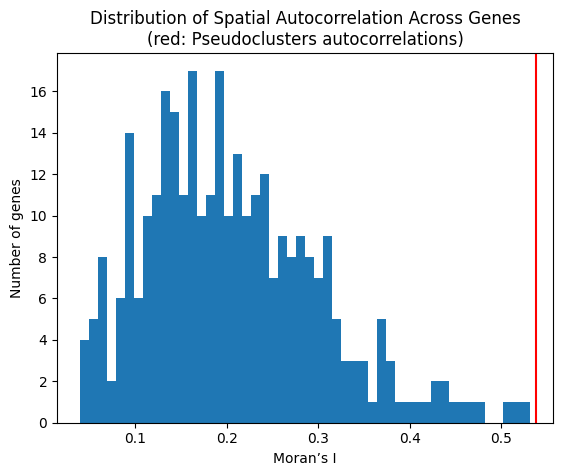

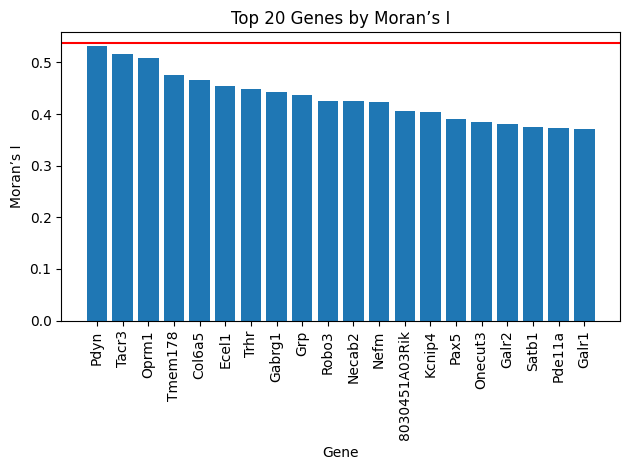

In [108]:

# 1) Histogram of all genes’ Moran’s I
plt.figure()
plt.hist(moranI_allgenes['I'], bins=50)
plt.xlabel("Moran’s I")
plt.ylabel("Number of genes")
plt.title("Distribution of Spatial Autocorrelation Across Genes\n(red: Pseudoclusters autocorrelations)")
plt.axvline(adata_mer.uns['moranI']['I'].pc, color='red')
plt.show()

# 2) Bar plot of the top 20 most spatially autocorrelated genes
top20 = moranI_allgenes['I'].sort_values(ascending=False).head(20)
plt.figure()
plt.bar(top20.index, top20.values)
plt.xticks(rotation=90)
plt.xlabel("Gene")
plt.ylabel("Moran’s I")
plt.title("Top 20 Genes by Moran’s I")
plt.axhline(adata_mer.uns['moranI']['I'].pc, color='red')
plt.tight_layout()
plt.show()

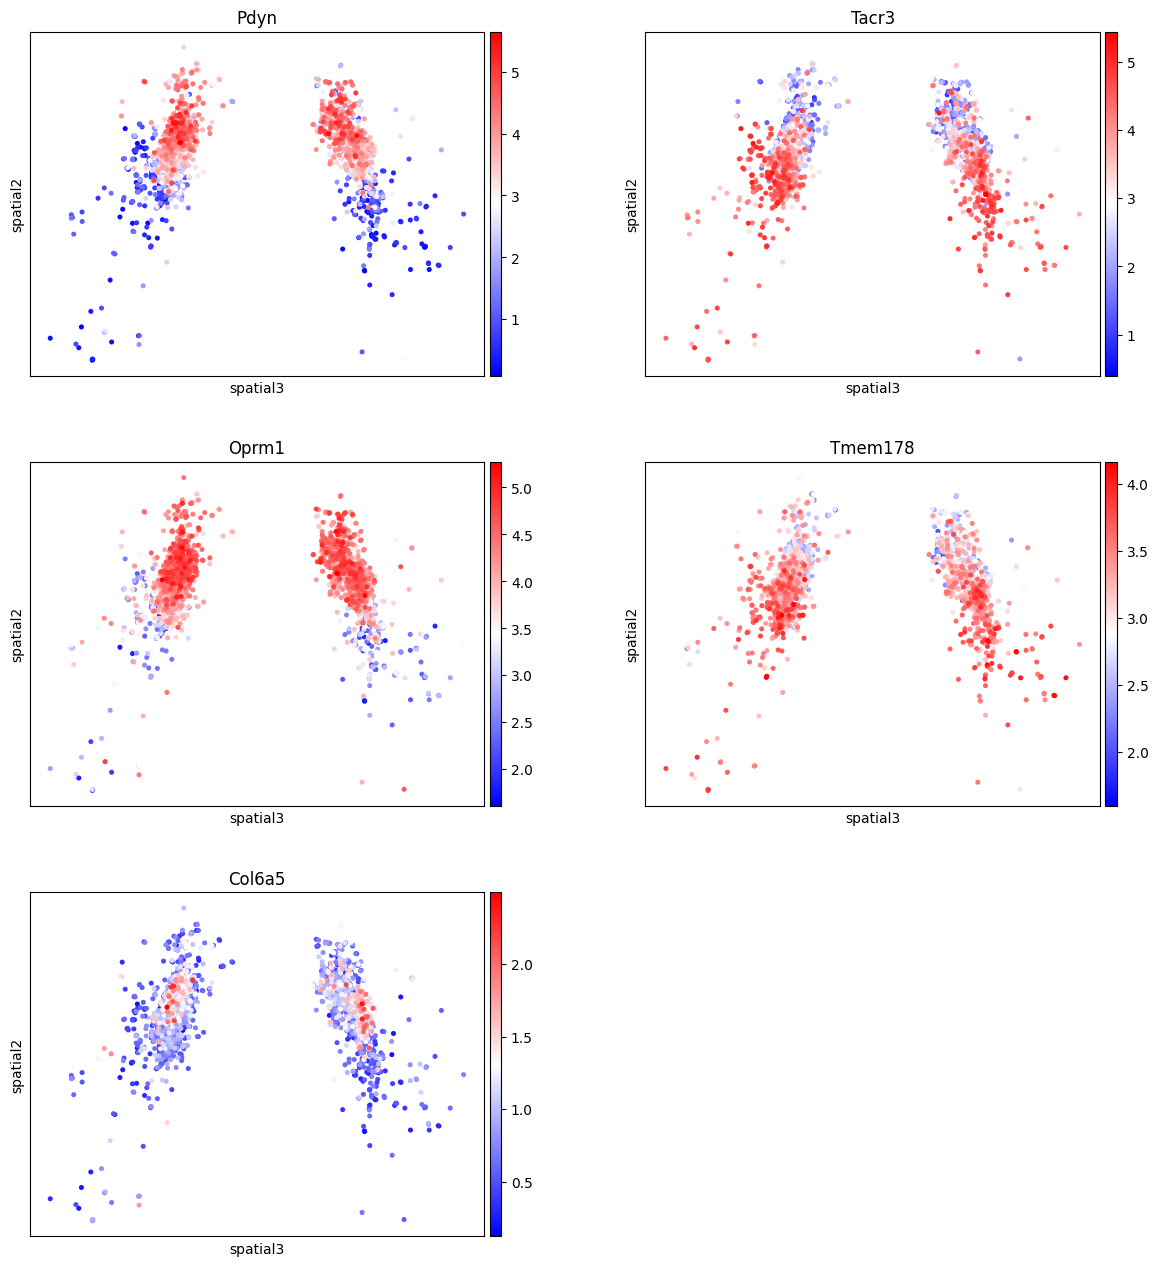

In [109]:
ax = sc.pl.embedding(adata_mer,basis = 'spatial', dimensions =(2,1), 
                color = moranI_allgenes['I'].sort_values(ascending=False).head(5).index,
                cmap = 'bwr', show = False, ncols = 2, 
               )
for a in ax: a.set_aspect('equal');a.invert_yaxis();

# variogram 

In [110]:
from sklearn.metrics import pairwise_distances

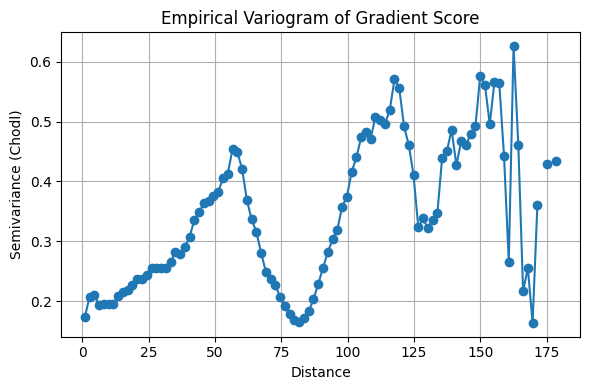

In [111]:
gene = 'Chodl'
# 1) Extract 3D coordinates and gradient score
coords = adata_mer.obs[['x_CCF', 'y_CCF', 'z_CCF']].values  # shape (n_cells, 3)
grad = adata_mer[:,gene].X.toarray() if gene != 'pc' else adata_mer.obs['pc'].astype(float).values    # 1D array of gradient scores

# 2) Compute pairwise distances and semivariances
dists = pairwise_distances(coords)  # (n_cells, n_cells)
semivariances = 0.5 * (grad[:, None] - grad[None, :])**2 

# 3) Take upper triangle (excluding diagonal) for analysis
iu = np.triu_indices_from(dists, k=1)
dist_vals = dists[iu]
semivar_vals = semivariances[iu]

# 4) Bin distances and compute average semivariance per bin
n_bins = 100
bins = np.linspace(dist_vals.min(), dist_vals.max(), n_bins + 1)
bin_idx = np.digitize(dist_vals, bins)
bin_centers = (bins[:-1] + bins[1:]) / 2

avg_semivar = [
    semivar_vals[bin_idx == i].mean() if np.any(bin_idx == i) else np.nan
    for i in range(1, len(bins))
]

# 5) Plot the variogram
plt.figure(figsize=(6, 4))
plt.plot(bin_centers, avg_semivar, marker='o', linestyle='-')
plt.xlabel("Distance")
plt.ylabel(f"Semivariance ({gene})")
plt.title("Empirical Variogram of Gradient Score")
plt.grid(True)
plt.tight_layout()
plt.show()


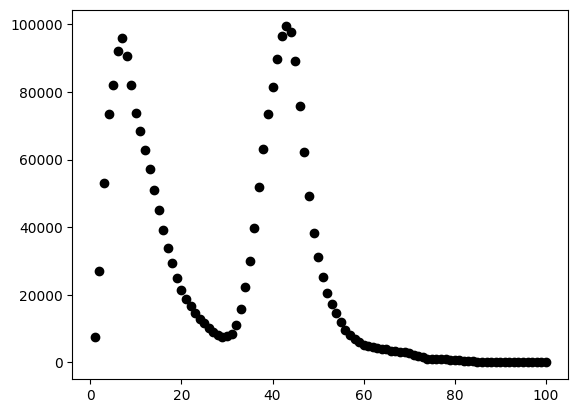

In [112]:
for i in range(1, len(bins)):
    plt.scatter(i,semivar_vals[bin_idx == i].shape[0], color='k')